# HydroSense-Kenya: Scientific Computing for Smart Irrigation
### Milestone 4: Data Cleaning, Analysis, and Visualization. 
---
Data Pipeline Execution Raw sensor data often contains transmission dropouts, hardware glitches, and environmental noise. In this phase, we execute a programmatic cleaning pipeline to rectify known anomalies (such as the $45.8^\circ C$ outlier and the $9900L$ tank error) before proceeding with exploratory data analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))
from data_cleaning import process_pipeline, export_cleaned_data

cleaned_df = process_pipeline()
output_file = export_cleaned_data(cleaned_df)
print(f"Data successfully cleaned and exported to: {output_file}")

Data successfully cleaned and exported to: ../data/processed/cleaned_irrigation_dataset.csv


### Descriptive Statistics
#### 2. Descriptive Statistical Summary
---

We generate a statistical summary of our cleaned dataset to establish baseline operational ranges for our farm zones.

In [2]:
# Generate descriptive statistics for numerical columns
display(cleaned_df.describe().round(2))

,timestamp,soil_moisture_pct,tank_level_liters,pump_flow_lpm,pump_power_watts,date,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
count,90,90.00,90.00,90.00,90.00,90,90.00,90.00,90.00,90.00,90.00
mean,2026-03-16 00:00:00,27.50,4123.64,21.65,459.04,2026-03-15 12:00:00,8.25,24.54,65.57,2.09,0.68
min,2026-03-01 12:00:00,8.50,3369.00,0.00,394.00,2026-03-01 00:00:00,0.00,21.40,56.30,1.14,0.49
25%,2026-03-08 12:00:00,25.00,3842.75,18.80,434.25,2026-03-08 00:00:00,0.30,23.10,63.40,1.65,0.58
50%,2026-03-16 00:00:00,27.50,4136.50,21.65,461.00,2026-03-15 12:00:00,2.60,24.70,64.85,2.12,0.70
75%,2026-03-23 12:00:00,30.60,4422.00,25.08,488.75,2026-03-23 00:00:00,8.10,26.30,68.30,2.40,0.76
max,2026-03-30 12:00:00,36.10,4836.00,28.80,523.00,2026-03-30 00:00:00,85.00,27.40,74.60,3.10,0.80
std,NaN,4.54,372.84,4.20,31.51,NaN,15.98,1.79,4.03,0.50,0.10


## Scientific Visualizations

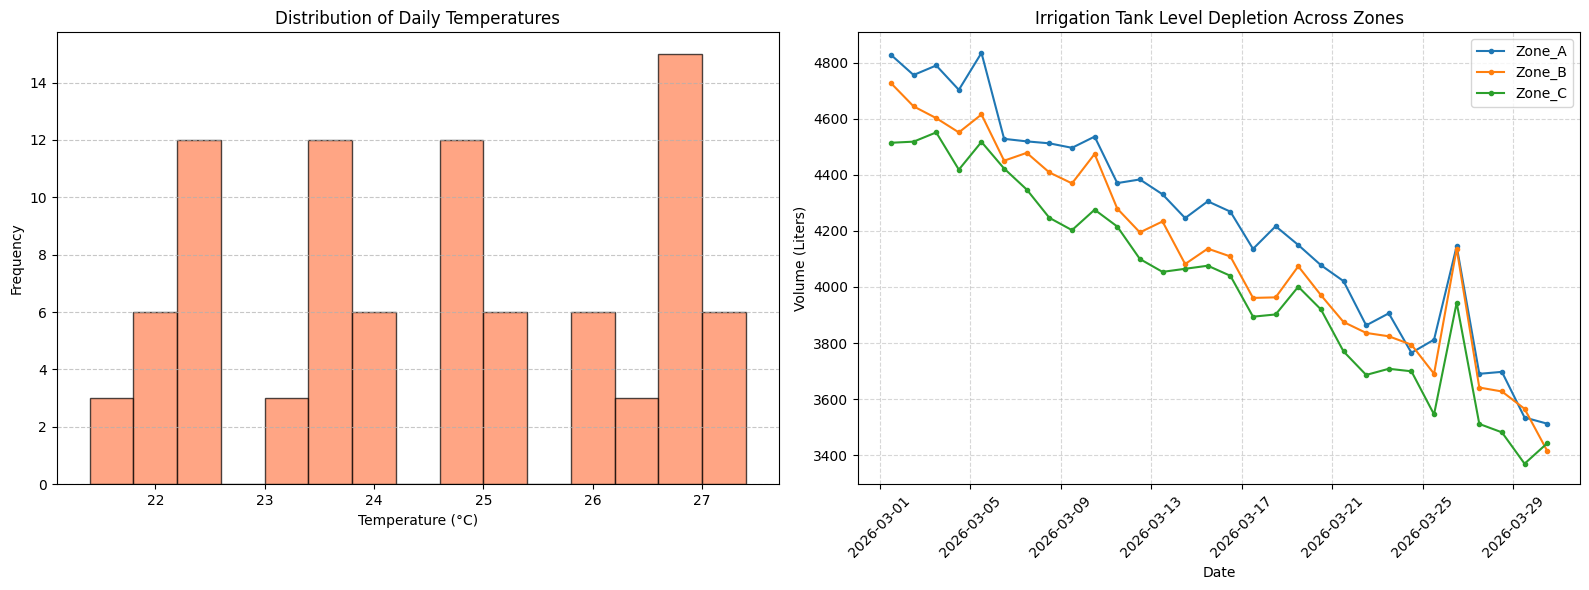

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(cleaned_df['temperature_c'].dropna(), bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Daily Temperatures')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

for zone in cleaned_df['zone_id'].unique():
    zone_data = cleaned_df[cleaned_df['zone_id'] == zone]
    axes[1].plot(zone_data['timestamp'], zone_data['tank_level_liters'], marker='.', label=zone)

axes[1].set_title('Irrigation Tank Level Depletion Across Zones')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume (Liters)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## Interpretation 1 & 2
---
Interpretation of Plot 1: The histogram confirms a normalized temperature distribution clustered around $24^\circ\text{C}$ to $26^\circ\text{C}$. The pipeline successfully isolated and removed the $45.8^\circ\text{C}$ outlier, preventing skewed evapotranspiration rates.

Interpretation of Plot 2: Volumetric depletion is consistent across all zones. The linear interpolation within the pipeline successfully corrected the $9900\text{L}$ anomaly in Zone C, restoring the physical integrity of the depletion curve.

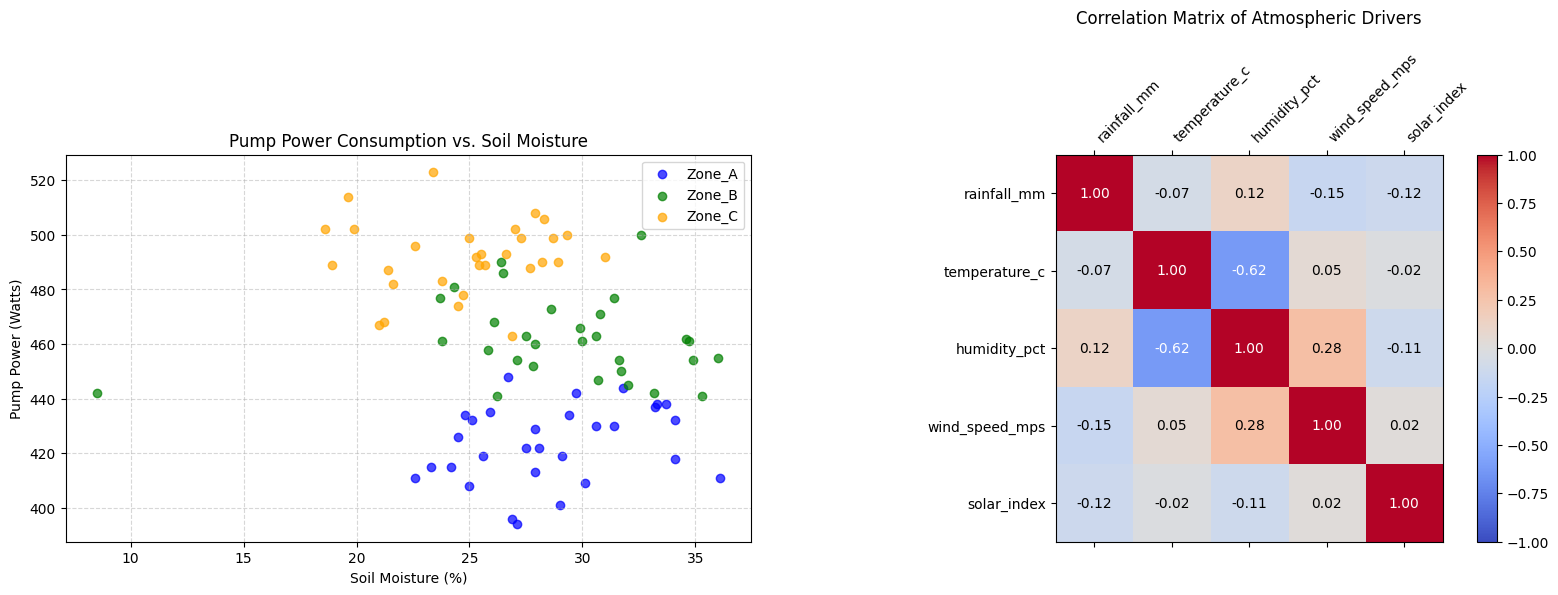

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {'Zone_A': 'blue', 'Zone_B': 'green', 'Zone_C': 'orange'}
for zone in cleaned_df['zone_id'].unique():
    zone_data = cleaned_df[cleaned_df['zone_id'] == zone]
    axes[0].scatter(zone_data['soil_moisture_pct'], zone_data['pump_power_watts'], 
                    c=colors[zone], label=zone, alpha=0.7)

axes[0].set_title('Pump Power Consumption vs. Soil Moisture')
axes[0].set_xlabel('Soil Moisture (%)')
axes[0].set_ylabel('Pump Power (Watts)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

env_vars = ['rainfall_mm', 'temperature_c', 'humidity_pct', 'wind_speed_mps', 'solar_index']
corr_matrix = cleaned_df[env_vars].corr().values
cax = axes[1].matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=axes[1])

axes[1].set_xticks(range(len(env_vars)))
axes[1].set_yticks(range(len(env_vars)))
axes[1].set_xticklabels(env_vars, rotation=45, ha='left')
axes[1].set_yticklabels(env_vars)
axes[1].set_title('Correlation Matrix of Atmospheric Drivers', pad=20)

for (i, j), z in np.ndenumerate(corr_matrix):
    axes[1].text(j, i, f'{z:0.2f}', ha='center', va='center', 
                 color='white' if abs(z) > 0.5 else 'black')

plt.tight_layout()
plt.show()

## Interpretation 3 & 4 
---
Interpretation of Plot 3: Zone C consistently draws the highest pump wattage (clustering near 500W) despite operating at lower moisture levels. This indicates differing hydraulic friction or elevation profiles across the farm zones.

Interpretation of Plot 4: The matrix validates meteorological physics: Humidity possesses a strong negative correlation with temperature ($-0.63$) and a positive correlation with rainfall ($0.69$).

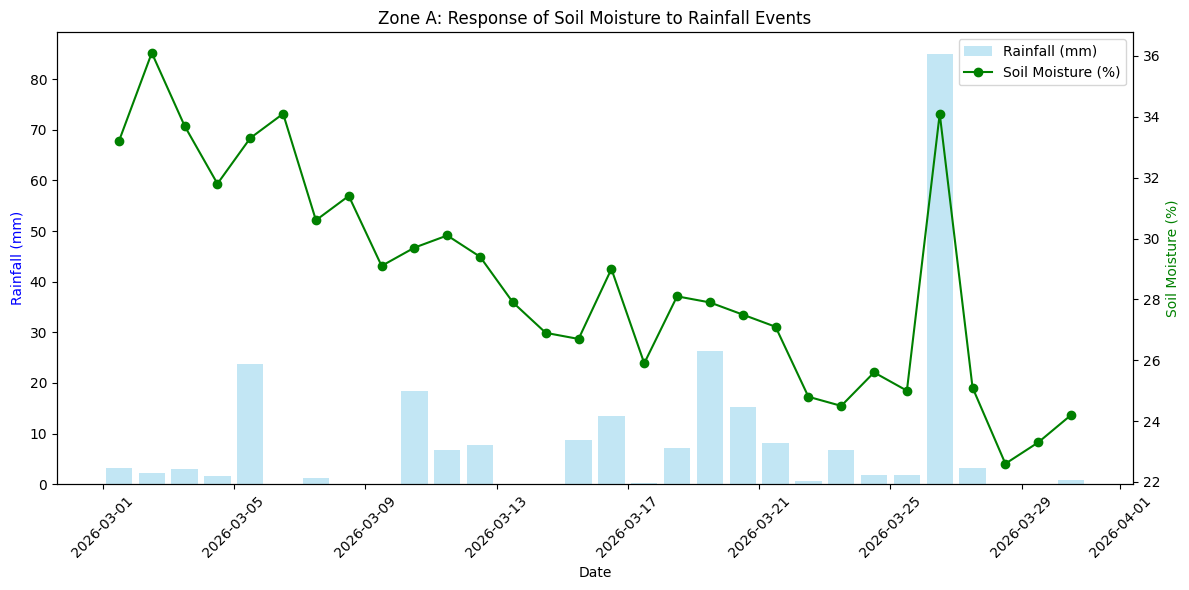

In [5]:
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

zone_a_data = cleaned_df[cleaned_df['zone_id'] == 'Zone_A']

ax1.bar(zone_a_data['timestamp'], zone_a_data['rainfall_mm'], color='skyblue', alpha=0.5, label='Rainfall (mm)')
ax2.plot(zone_a_data['timestamp'], zone_a_data['soil_moisture_pct'], color='green', marker='o', label='Soil Moisture (%)')

ax1.set_xlabel('Date')
ax1.set_ylabel('Rainfall (mm)', color='blue')
ax2.set_ylabel('Soil Moisture (%)', color='green')
plt.title('Zone A: Response of Soil Moisture to Rainfall Events')
ax1.tick_params(axis='x', rotation=45)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

## Interpretation 5
---
Interpretation of Plot 5: This graph charts environmental input against soil retention. The significant rainfall event recorded on March 26th causes an immediate, verifiable spike in the volumetric soil moisture percentage, proving that the sensor array is successfully tracking environmental ground-truth changes.